Imports e lettura dei dati

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)

In [3]:
actors = pd.read_csv('dataSets/mainDataSet/actors.csv')
countries = pd.read_csv('dataSets/mainDataSet/countries.csv')
crew = pd.read_csv('dataSets/mainDataSet/crew.csv')
genres = pd.read_csv('dataSets/mainDataSet/genres.csv')
languages = pd.read_csv('dataSets/mainDataSet/languages.csv')
movies = pd.read_csv('dataSets/mainDataSet/movies.csv')
posters = pd.read_csv('dataSets/mainDataSet/posters.csv') #potrebbe non servire in analisi dati
releases = pd.read_csv('dataSets/mainDataSet/releases.csv') #potrebbe non servire in analisi dati
studios = pd.read_csv('dataSets/mainDataSet/studios.csv')
themes = pd.read_csv('dataSets/mainDataSet/themes.csv') #potrebbe non servire in analisi dati
reviews = pd.read_csv('dataSets/additionalData/rotten_tomatoes_reviews.csv')
oscar=pd.read_csv('dataSets/additionalData/the_oscar_awards.csv')

In [4]:
actors

,id,name,role
0,1000001,Margot Robbie,Barbie
1,1000001,Ryan Gosling,Ken
2,1000001,America Ferrera,Gloria
3,1000001,Ariana Greenblatt,Sasha
4,1000001,Issa Rae,Barbie
...,...,...,...
5798445,1941596,Marc Ma,Ba Cai/巴莱
5798446,1941596,线雨轩,Tata/塔塔
5798447,1941596,Jiang Yixuan,Zuo Yila（Zoila）/佐伊拉
5798448,1941597,Hiroshi Mikami,NaN


In [5]:
genres['genre'].value_counts()

genre
Drama              232201
Documentary        163890
Comedy             140636
Animation           58708
Horror              53870
Romance             51549
Thriller            46726
Music               44105
Action              41695
Crime               35507
Family              27511
TV Movie            25874
Adventure           23093
Fantasy             22280
Mystery             21394
Science Fiction     21209
History             17008
War                 10758
Western              8835
Name: count, dtype: int64

In [6]:
genres['genre'].nunique()

19

In [7]:
genres

,id,genre
0,1000001,Comedy
1,1000001,Adventure
2,1000002,Comedy
3,1000002,Thriller
4,1000002,Drama
...,...,...
1046844,1941563,Drama
1046845,1941566,Crime
1046846,1941569,Crime
1046847,1941596,Action


In [8]:
languages

,id,type,language
0,1000001,Language,English
1,1000002,Primary language,Korean
2,1000002,Spoken language,English
3,1000002,Spoken language,German
4,1000002,Spoken language,Korean
...,...,...,...
1038757,1941593,Language,Chinese
1038758,1941594,Language,English
1038759,1941595,Language,English
1038760,1941596,Language,Chinese


capire il dataset

In [9]:
countries.nunique()

id         617192
country       247
dtype: int64

In [10]:
countries['country'].value_counts()

country
USA                                  174489
France                                45725
UK                                    42914
Japan                                 41362
Germany                               41325
                                      ...  
Niue                                      2
Heard Island and McDonald Islands         2
Cocos (Keeling) Islands                   1
Bouvet Island                             1
Norfolk Island                            1
Name: count, Length: 247, dtype: int64

creo un subset di countries di paesi di interesse geopolitico e culturale, di paesi con piu film o paesi di interesse personale


In [11]:
paesi_di_interesse = [
    "USA", "France", "UK", "Japan", "Germany", "India", "Italy",
    "Mexico", "China", "Russian Federation", "South Korea", "USSR",
    "Philippines", "Czechoslovakia", "Poland", "Turkey",
    "Taiwan", "Czechia", "Iran", "Ukraine", "Ireland", "Israel",
    "South Africa", "Malaysia", "New Zealand", "Colombia", "East Germany",
    "Croatia", "Serbia", "Bulgaria", "Slovakia", "Kazakhstan"
]
sub_countries = countries[countries['country'].isin(paesi_di_interesse)]

In [12]:
sub_countries.count()

id         504888
country    504888
dtype: int64

creo un subset di film basato sul subset di countries di interesse

In [13]:
movies

,id,name,date,tagline,description,minute,rating
0,1000001,Barbie,2023.0,She's everything. He's just Ken.,Barbie and Ken are having the time of their li...,114.0,3.86
1,1000002,Parasite,2019.0,Act like you own the place.,"All unemployed, Ki-taek's family takes peculia...",133.0,4.56
2,1000003,Everything Everywhere All at Once,2022.0,The universe is so much bigger than you realize.,An aging Chinese immigrant is swept up in an i...,140.0,4.30
3,1000004,Fight Club,1999.0,Mischief. Mayhem. Soap.,A ticking-time-bomb insomniac and a slippery s...,139.0,4.27
4,1000005,La La Land,2016.0,Here's to the fools who dream.,"Mia, an aspiring actress, serves lattes to mov...",129.0,4.09
...,...,...,...,...,...,...,...
941592,1941593,神笛,NaN,NaN,NaN,NaN,NaN
941593,1941594,蟲極道蜜団子抗争編 壱ノ巻,NaN,NaN,Shinjuku forest at night. In the sap taverns o...,30.0,NaN
941594,1941595,蟲極道蜜団子抗争編 弐ノ巻,NaN,NaN,"The city that never sleeps, where insects gath...",30.0,NaN
941595,1941596,重生,NaN,NaN,"In a world where order has broken down, darkne...",NaN,NaN


In [14]:
id_filtrati = sub_countries['id'].unique()
df = movies[movies['id'].isin(id_filtrati)].copy()

In [15]:
df.count()

id             472298
name           472297
date           454522
tagline         89355
description    403126
minute         409236
rating          75496
dtype: int64

In [16]:
#creo dataframe, per ogni id di un film crea una lista contenente i paesi che l'hanno prodotto
#countries_aggregated = countries.groupby('id')['country'].apply(list).reset_index()

# Unisce il dataset dei film con i paesi aggregati
#df = pd.merge(movies_filtrati, countries_aggregated, on='id', how='inner')

In [17]:
#df

Merging all Data-sets by id

In [18]:
# Unisci i primi due dataset
#df = pd.merge(movies, countries, on='id', how='inner')

# Unisci il risultato con il terzo dataset
#df = pd.merge(df, ds3, on='id', how='inner')

# Continua fino a unire tutti i dataset
#df = pd.merge(df, ds4, on='id', how='inner')
#df = pd.merge(df, ds5, on='id', how='inner')
#df = pd.merge(df, ds6, on='id', how='inner')
#df = pd.merge(df, ds7, on='id', how='inner')
#df = pd.merge(df, ds8, on='id', how='inner')
#df = pd.merge(df, ds9, on='id', how='inner')
#df.head(1000)

pulizia dei dati

In [19]:
df

,id,name,date,tagline,description,minute,rating
0,1000001,Barbie,2023.0,She's everything. He's just Ken.,Barbie and Ken are having the time of their li...,114.0,3.86
1,1000002,Parasite,2019.0,Act like you own the place.,"All unemployed, Ki-taek's family takes peculia...",133.0,4.56
2,1000003,Everything Everywhere All at Once,2022.0,The universe is so much bigger than you realize.,An aging Chinese immigrant is swept up in an i...,140.0,4.30
3,1000004,Fight Club,1999.0,Mischief. Mayhem. Soap.,A ticking-time-bomb insomniac and a slippery s...,139.0,4.27
4,1000005,La La Land,2016.0,Here's to the fools who dream.,"Mia, an aspiring actress, serves lattes to mov...",129.0,4.09
...,...,...,...,...,...,...,...
941592,1941593,神笛,NaN,NaN,NaN,NaN,NaN
941593,1941594,蟲極道蜜団子抗争編 壱ノ巻,NaN,NaN,Shinjuku forest at night. In the sap taverns o...,30.0,NaN
941594,1941595,蟲極道蜜団子抗争編 弐ノ巻,NaN,NaN,"The city that never sleeps, where insects gath...",30.0,NaN
941595,1941596,重生,NaN,NaN,"In a world where order has broken down, darkne...",NaN,NaN


In [20]:
df.loc[df.duplicated(subset=['name', 'date', 'minute'])]

,id,name,date,tagline,description,minute,rating
41484,1041485,The Haunted Castle,1897.0,NaN,George Albert Smith's remake of Georges Méliès...,1.0,2.85
42715,1042716,The Darkness,2016.0,NaN,A family lives in a cabin in the middle of a s...,92.0,3.18
65400,1065401,Disclosure,2020.0,"There are two sides to every story, and then t...","Australian documentary maker Emily, and her jo...",107.0,3.44
73818,1073819,Better Than Sex,2000.0,3 days in the life of a 1 night stand.,After a one-night stand a couple is faced with...,84.0,3.24
73819,1073820,Amoklauf,1994.0,NaN,A nameless waiter spends his days sitting arou...,65.0,NaN
...,...,...,...,...,...,...,...
941049,1941050,The Bunker,NaN,We haven't much time...decide!,"On the brink of nuclear destruction, a mother ...",NaN,NaN
941088,1941089,The Daily Life of a Sexist Homosexual,NaN,NaN,This is what happens if you make a mockumentar...,24.0,NaN
941091,1941092,Dead in Love,NaN,It's never too late to come out... or fall in ...,The ghost of a bisexual young woman becomes en...,105.0,NaN
941120,1941121,Don't. Get. Out! 2,NaN,NaN,NaN,NaN,NaN


cancello tutte le righe duplicate

In [21]:
df = df.loc[~df.duplicated(subset=['name', 'date', 'minute'])].reset_index(drop=True).copy() #identifico come duplicati tutti i film con stesso nome data e durata

In [22]:
df.count()

id             470991
name           470990
date           453350
tagline         89200
description    402141
minute         408280
rating          75477
dtype: int64

In [23]:
df.loc[df['name'] == 'untitled']

,id,name,date,tagline,description,minute,rating
143056,1189343,untitled,NaN,NaN,NaN,NaN,NaN
203811,1295520,untitled,1994.0,NaN,NaN,NaN,NaN
204340,1296524,untitled,1996.0,NaN,NaN,NaN,NaN
204345,1296533,untitled,1993.0,NaN,NaN,NaN,NaN
204901,1297545,untitled,1995.0,NaN,NaN,NaN,NaN
205444,1298628,untitled,1992.0,NaN,NaN,NaN,NaN
467449,1933305,untitled,2019.0,NaN,NaN,3.0,NaN


cancello tutte le righe con nome del film "untitled"

In [24]:
maschera_da_eliminare = df['name'] == 'untitled'
df = df.drop(df[maschera_da_eliminare].index).copy()

cambio la colonna date in release_year

In [25]:
df = df.rename(columns={'date': 'release_year'}).copy()
df

,id,name,release_year,tagline,description,minute,rating
0,1000001,Barbie,2023.0,She's everything. He's just Ken.,Barbie and Ken are having the time of their li...,114.0,3.86
1,1000002,Parasite,2019.0,Act like you own the place.,"All unemployed, Ki-taek's family takes peculia...",133.0,4.56
2,1000003,Everything Everywhere All at Once,2022.0,The universe is so much bigger than you realize.,An aging Chinese immigrant is swept up in an i...,140.0,4.30
3,1000004,Fight Club,1999.0,Mischief. Mayhem. Soap.,A ticking-time-bomb insomniac and a slippery s...,139.0,4.27
4,1000005,La La Land,2016.0,Here's to the fools who dream.,"Mia, an aspiring actress, serves lattes to mov...",129.0,4.09
...,...,...,...,...,...,...,...
470986,1941593,神笛,NaN,NaN,NaN,NaN,NaN
470987,1941594,蟲極道蜜団子抗争編 壱ノ巻,NaN,NaN,Shinjuku forest at night. In the sap taverns o...,30.0,NaN
470988,1941595,蟲極道蜜団子抗争編 弐ノ巻,NaN,NaN,"The city that never sleeps, where insects gath...",30.0,NaN
470989,1941596,重生,NaN,NaN,"In a world where order has broken down, darkne...",NaN,NaN


In [26]:
df.dtypes

id                int64
name             object
release_year    float64
tagline          object
description      object
minute          float64
rating          float64
dtype: object

prime analisi?

In [27]:
df['release_year'].value_counts()

release_year
2023.0    21518
2021.0    18791
2022.0    18762
2019.0    17420
2020.0    17312
          ...  
1882.0        2
1874.0        1
2031.0        1
1885.0        1
1887.0        1
Name: count, Length: 149, dtype: int64

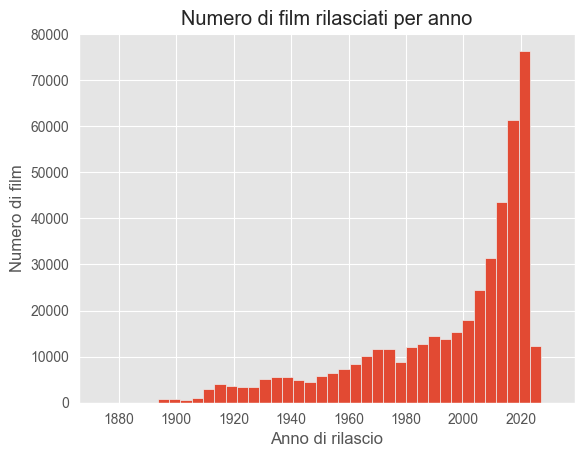

In [28]:
ax = df['release_year'].plot(kind='hist', bins=40, title='Numero di film rilasciati per anno')
ax.set_xlabel('Anno di rilascio')
ax.set_ylabel('Numero di film')
plt.show()

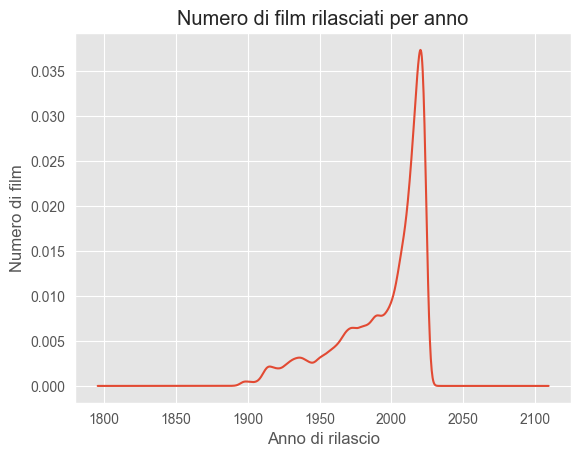

In [29]:
ax = df['release_year'].plot(kind='kde', title='Numero di film rilasciati per anno')
ax.set_xlabel('Anno di rilascio')
ax.set_ylabel('Numero di film')
plt.show()

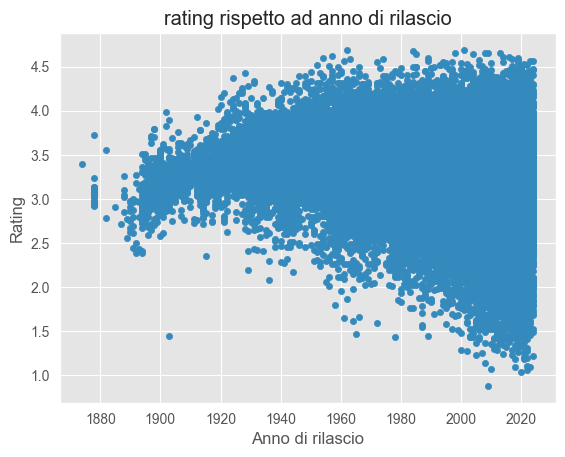

In [30]:
ax = df.plot(kind='scatter', x='release_year', y='rating', title='rating rispetto ad anno di rilascio')
ax.set_xlabel('Anno di rilascio')
ax.set_ylabel('Rating')
plt.show()

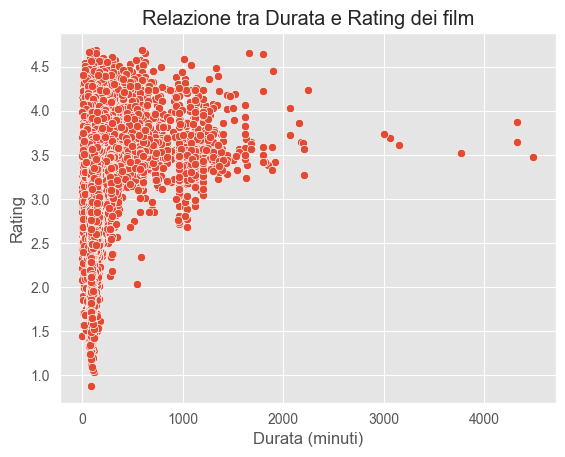

In [31]:
sns.scatterplot(x='minute', y='rating', data=df)
plt.xlabel('Durata (minuti)')
plt.ylabel('Rating')
plt.title('Relazione tra Durata e Rating dei film')
plt.show()

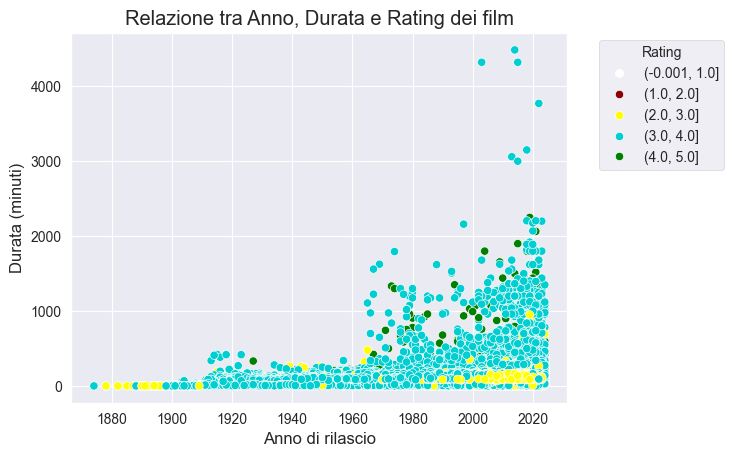

In [46]:
# Crea gli intervalli di 1,0 da 0 a 5
bins = np.arange(0, 6, 1)  # Crea intervalli: [0, 1, 2, 3, 4, 5]

# Raggruppa i rating in questi intervalli
df['rating_group'] = pd.cut(df['rating'], bins=bins, include_lowest=True)

# Definisci la palette personalizzata usando oggetti Interval
custom_palette = {
    pd.Interval(-0.001, 1.0, closed='right'): '#FFFFFF',  # Nero per 0-1
    pd.Interval(1.0, 2.0, closed='right'): '#8B0000',     # Rosso scuro per 1-2
    pd.Interval(2.0, 3.0, closed='right'): '#FFFF00',     # Giallo per 2-3
    pd.Interval(3.0, 4.0, closed='right'): '#00CED1',     # Celeste per 3-4
    pd.Interval(4.0, 5.0, closed='right'): '#008000'      # Verde per 4-5
}

# Crea il grafico
sns.scatterplot(x='release_year', y='minute', hue='rating_group', palette=custom_palette, data=df)
plt.xlabel('Anno di rilascio')
plt.ylabel('Durata (minuti)')
plt.title('Relazione tra Anno, Durata e Rating dei film')
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')  # Legenda fuori dal grafico
plt.show()

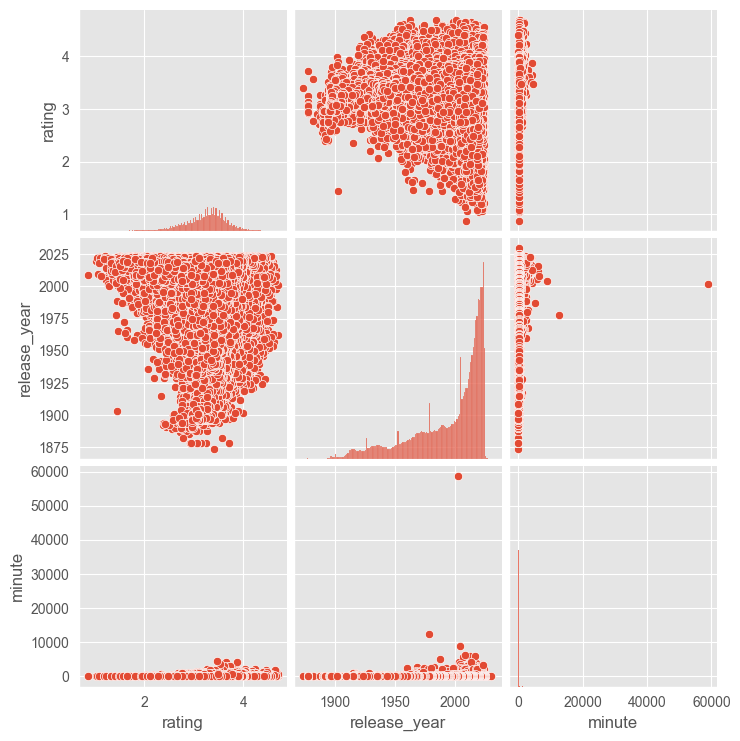

In [33]:
sns.pairplot(data=df, vars=['rating', 'release_year', 'minute'])
plt.show()

In [34]:
df[df['minute']>400]

,id,name,release_year,tagline,description,minute,rating
451,1000455,Squid Game,2021.0,"45,6 Billion Won Is Child's Play",Hundreds of cash-strapped players accept a str...,495.0,3.73
640,1000648,Loki,2021.0,Loki's time has come.,After stealing the Tesseract during the events...,615.0,3.78
1077,1001094,The Haunting of Hill House,2018.0,You're expected,"The Crains, a fractured family, confront haunt...",575.0,4.33
1436,1001459,Twin Peaks: The Return,2017.0,It is happening again.,Picks up 25 years after the inhabitants of a q...,1014.0,4.59
1518,1001543,Neon Genesis Evangelion,1995.0,NaN,"At the turn of the century, the Angels returne...",615.0,4.54
...,...,...,...,...,...,...,...
469833,1940143,Antihero,2024.0,NaN,Japan has a conviction rate of 99.9% for crimi...,680.0,NaN
469835,1940146,ACMA:GAME,2024.0,NaN,It is said that if you collect 99 devil's keys...,450.0,NaN
469846,1940160,The Great Passage: I'll Make a Dictionary,2024.0,NaN,"Kishibe Midori (Ikeda Elaiza), an editor for a...",490.0,NaN
469916,1940257,The Real Has Come!,2023.0,NaN,A successful lecturer facing single motherhood...,3500.0,NaN


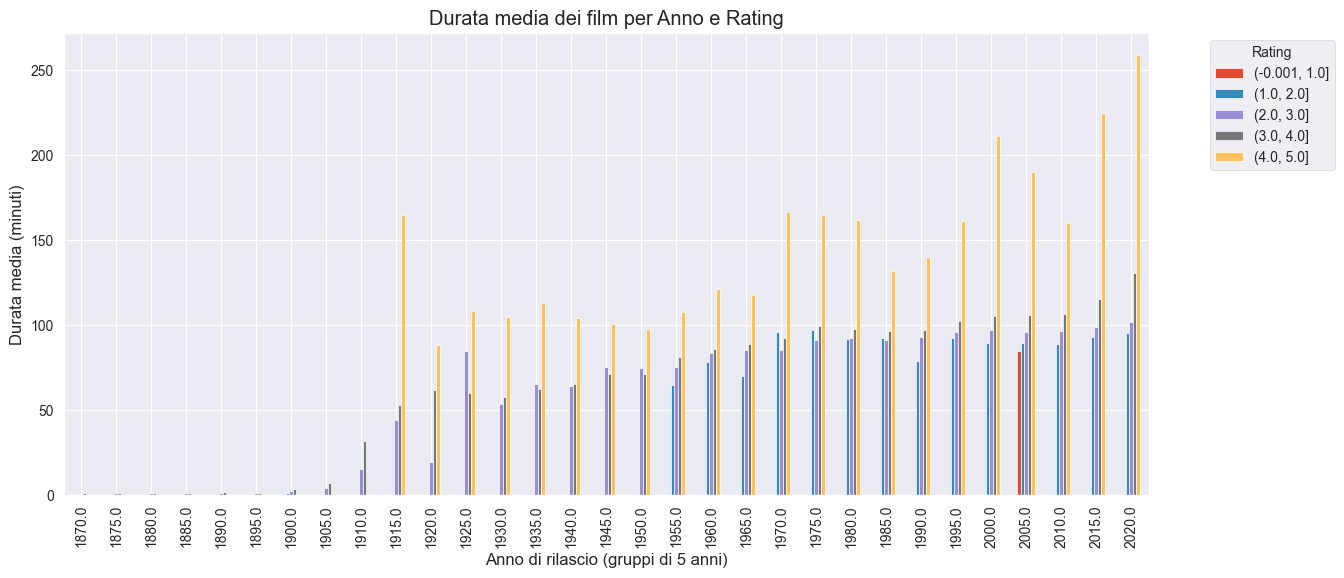

In [56]:
# Crea gli intervalli di rating
df['rating_group'] = pd.cut(df['rating'], bins=[0, 1, 2, 3, 4, 5], include_lowest=True)

# Raggruppa gli anni in intervalli di 5 anni
df['year_group'] = (df['release_year'] // 5) * 5  # Esempio: 1990-1994, 1995-1999, ecc.

# Aggrega i dati per gruppo di anni e rating, calcolando la durata media
df_agg = df.groupby(['year_group', 'rating_group'], observed=True)['minute'].mean().unstack()

# Crea il grafico a barre
df_agg.plot(kind='bar', stacked=False, figsize=(14, 6))  # stacked=False per barre affiancate
plt.xlabel('Anno di rilascio (gruppi di 5 anni)')
plt.ylabel('Durata media (minuti)')
plt.title('Durata media dei film per Anno e Rating')
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

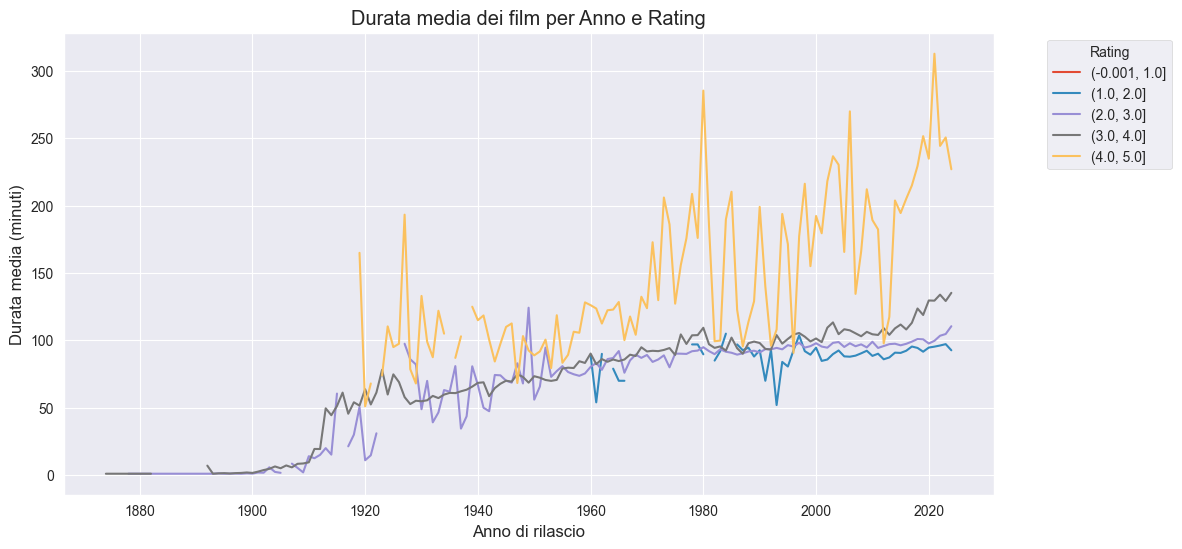

In [60]:
# Calcola la durata media per anno e rating
df_avg = df.groupby(['release_year', 'rating_group'], observed=True)['minute'].mean().unstack()

# Crea il grafico a linee
df_avg.plot(kind='line', figsize=(12, 6))
plt.xlabel('Anno di rilascio')
plt.ylabel('Durata media (minuti)')
plt.title('Durata media dei film per Anno e Rating')
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

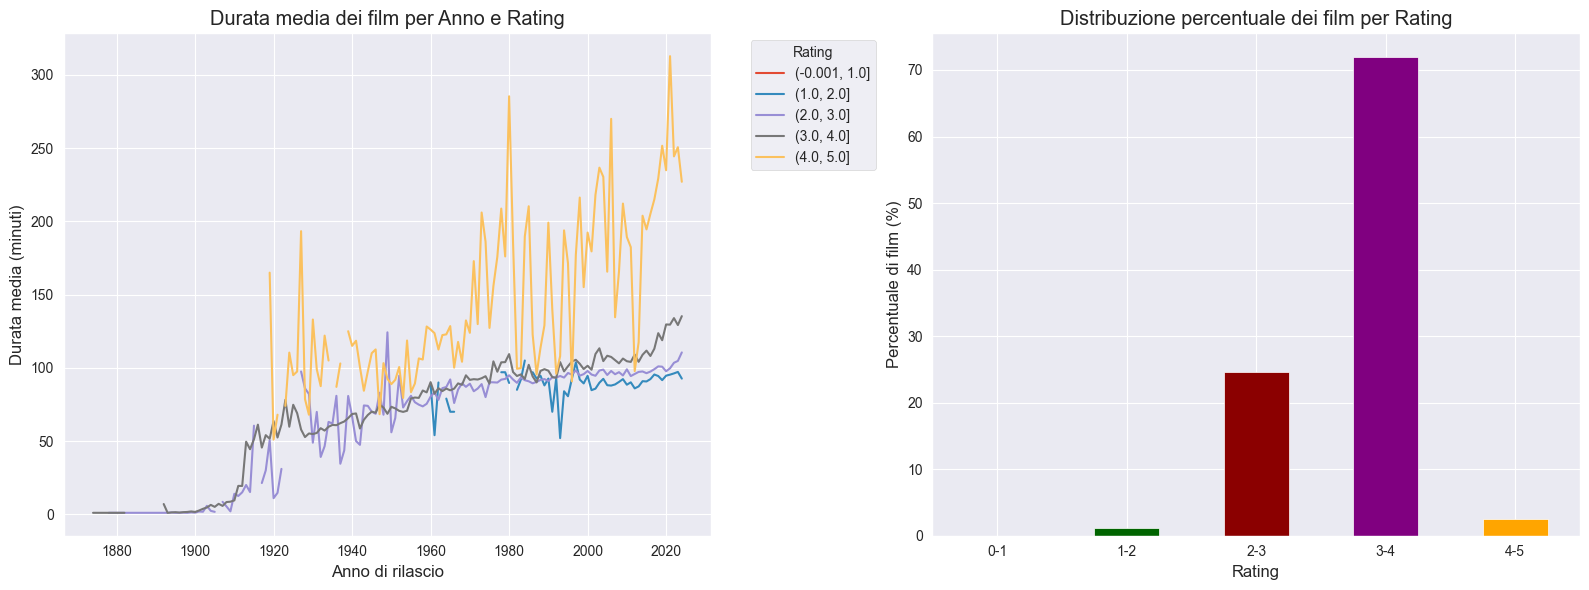

In [72]:
# Crea gli intervalli di rating
df['rating_group'] = pd.cut(df['rating'], bins=[0, 1, 2, 3, 4, 5], include_lowest=True)

# Calcola la durata media per anno e rating
df_avg = df.groupby(['release_year', 'rating_group'], observed=True)['minute'].mean().unstack()

# Calcola la distribuzione percentuale dei film per rating
rating_percent = df['rating_group'].value_counts(normalize=True) * 100

# Crea una figura con due subplot affiancati
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Grafico a linee per la durata media
df_avg.plot(kind='line', ax=ax1)
ax1.set_xlabel('Anno di rilascio')
ax1.set_ylabel('Durata media (minuti)')
ax1.set_title('Durata media dei film per Anno e Rating')
ax1.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')

# Grafico a barre per la distribuzione percentuale dei film per rating
rating_percent.sort_index().plot(kind='bar', ax=ax2, color=['darkblue', 'darkgreen', 'darkred', 'purple', 'orange'])
ax2.set_xlabel('Rating')
ax2.set_ylabel('Percentuale di film (%)')
ax2.set_title('Distribuzione percentuale dei film per Rating')
ax2.set_xticklabels(['0-1', '1-2', '2-3', '3-4', '4-5'], rotation=0)  # Etichette più leggibili

plt.tight_layout()
plt.show()

C:\Users\pc\AppData\Local\Temp\ipykernel_16880\1112497788.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='rating_group', y='minute', data=df, ax=ax2, palette=['darkblue', 'darkgreen', 'darkred', 'purple', 'orange'])
C:\Users\pc\AppData\Local\Temp\ipykernel_16880\1112497788.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['0-1', '1-2', '2-3', '3-4', '4-5'])  # Etichette più leggibili


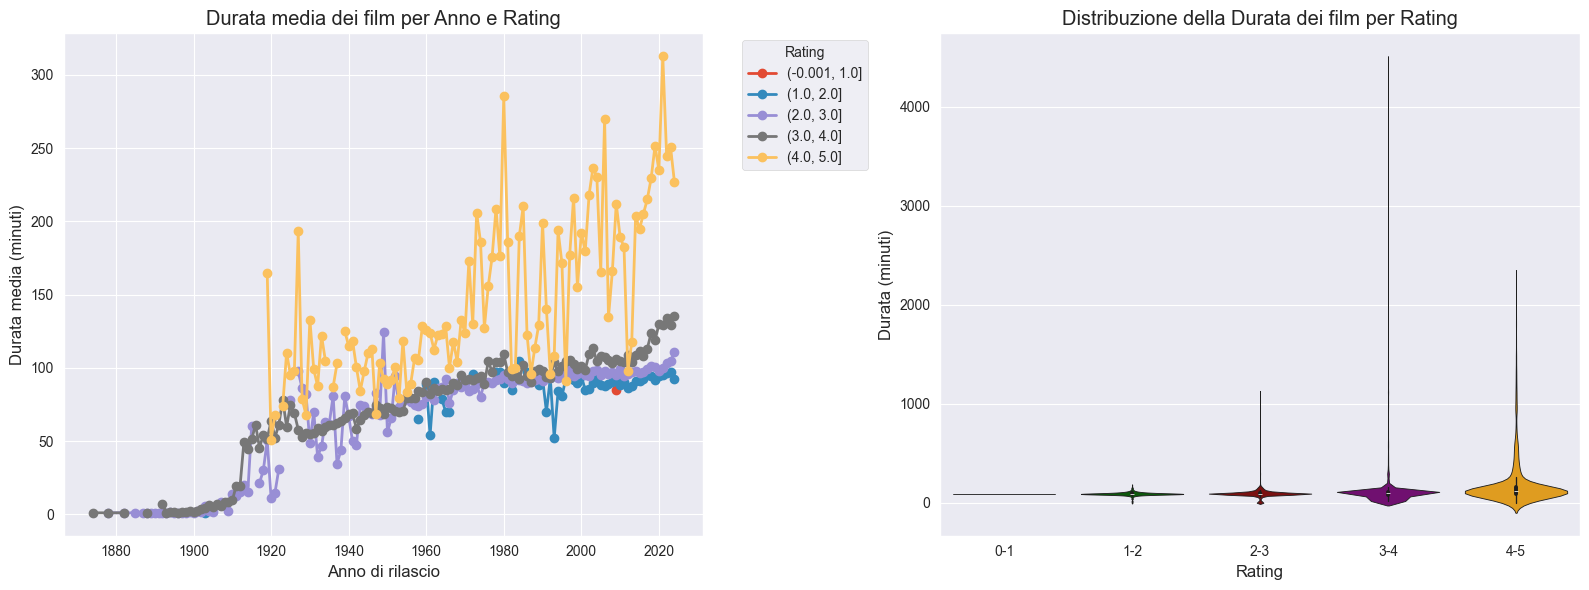

In [69]:
# Crea gli intervalli di rating
df['rating_group'] = pd.cut(df['rating'], bins=[0, 1, 2, 3, 4, 5], include_lowest=True)

# Crea una figura con due subplot affiancati
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Grafico a linee per la durata media
df_avg = df.groupby(['release_year', 'rating_group'], observed=True)['minute'].mean().unstack()
df_avg.plot(kind='line', ax=ax1, marker='o', linestyle='-', linewidth=2)
ax1.set_xlabel('Anno di rilascio')
ax1.set_ylabel('Durata media (minuti)')
ax1.set_title('Durata media dei film per Anno e Rating')
ax1.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')

# Violin plot per la distribuzione della durata dei film per rating
sns.violinplot(x='rating_group', y='minute', data=df, ax=ax2, palette=['darkblue', 'darkgreen', 'darkred', 'purple', 'orange'])
ax2.set_xlabel('Rating')
ax2.set_ylabel('Durata (minuti)')
ax2.set_title('Distribuzione della Durata dei film per Rating')
ax2.set_xticklabels(['0-1', '1-2', '2-3', '3-4', '4-5'])  # Etichette più leggibil

plt.tight_layout()
plt.show()